In [1]:
from resources.imports import *

import torch
import torch.nn as nn

from resources.MLdata import DATA
from resources.MLfunc import EarlyStopping, CombinedCurveLoss
from resources.MLmodels import *

In [2]:
%load_ext autoreload
%autoreload 2

# Stress-Strain Curve

## Multi-Layer Perceptrion (MLP)

In [3]:
DAT_MLP = DATA(
    path=1, 
    path_add="",
    load=True, 
    load_split=False,
    split_frac=0.9,
    save_split=False,
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2,
    d_data="in",
    mechMode="UT",
    nsims=None,
    model="MLP",
    scale=("symm", "in"),
    reduce_dim=False #("PCA", "out", 0.95, 10, True)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
DAT = DAT_MLP
if DAT.UTmechTest:
    print("UT shape:", DAT.UT_train_in.shape, DAT.UT_train_out.shape)
    print("Train -  in (min, max):", DAT.UT_train_in.min(), DAT.UT_train_in.max(), "\n        out (min, max):", DAT.UT_train_out.min(), DAT.UT_train_out.max())
    print("  Val -  in (min, max):", DAT.UT_val_in.min(), DAT.UT_val_in.max(), "\n        out (min, max):", DAT.UT_val_out.min(), DAT.UT_val_out.max())
    print(" Test -  in (min, max):", DAT.UT_test_in.min(), DAT.UT_test_in.max(), "\n        out (min, max):", DAT.UT_test_out.min(), DAT.UT_test_out.max())
    if DAT.FTmechTest: print("\n========================================================\n")
if DAT.FTmechTest:
    print("FT shape:", DAT.FT_train_in.shape, DAT.FT_train_out.shape)
    print("Train -  in (min, max):", DAT.FT_train_in.min(), DAT.FT_train_in.max(), "\n        out (min, max):", DAT.FT_train_out.min(), DAT.FT_train_out.max())
    print("  Val -  in (min, max):", DAT.FT_val_in.min(), DAT.FT_val_in.max(), "\n        out (min, max):", DAT.FT_val_out.min(), DAT.FT_val_out.max())
    print(" Test -  in (min, max):", DAT.FT_test_in.min(), DAT.FT_test_in.max(), "\n        out (min, max):", DAT.FT_test_out.min(), DAT.FT_test_out.max())

UT shape: (5560, 1444) (5560, 201)
Train -  in (min, max): -1.0 1.0 
        out (min, max): 0.0 63.50968603027344
  Val -  in (min, max): -1.0021826921779824 1.0015446136377668 
        out (min, max): 0.0 62.161322421875
 Test -  in (min, max): -1.0019228134810694 1.001480207186519 
        out (min, max): 0.0 62.28637612304688


In [5]:
MLP1 = MODEL(
    typ=DAT.model,
    model=MLP(in_size=DAT.UT_train_in.shape[-1], 
              h_size=[4096, 2048, 1024, 1024, 1024, 512, 512], 
              out_size=DAT.UT_train_out.shape[-1], 
              act="relu",
              block="mlp",
              norm="batch", 
              dropout=0.0).to(device), 
    lossf=CustomQuantileLossMATLAB(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(67, 134), err_type="L2"), #nn.MSELoss(reduction="mean"), #CustomQuantileLoss(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(50, 150), err_type="L2"),
    opt=("adam", 6.016e-6), #("adam", 1e-4),
    batch=32,
    lr=9e-4,
    data=DAT,
    mechMode=DAT.mechMode,
    scheduler=("min", 0.2427, 100, 1e-4), #("min", 0.2427, 18, 1e-4), 
    earlyStop=EarlyStopping(patience=500, min_delta=1e-4, verbose=True),
    w_init="auto",
    device=device,
    optTrial=None,
    scan_matches_on_init=True
)

MLP1.summary()

[MODEL scan] strict matches: 0
[MODEL scan] coarse-only matches: 0


Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [32, 201]                 --
â”œâ”€Linear: 1-1                            [32, 4096]                5,918,720
â”œâ”€BatchNorm1d: 1-2                       [32, 4096]                8,192
â”œâ”€ReLU: 1-3                              [32, 4096]                --
â”œâ”€ModuleList: 1-4                        --                        --
â”‚    â””â”€mlpBlock: 2-1                     [32, 2048]                --
â”‚    â”‚    â””â”€Linear: 3-1                  [32, 2048]                8,390,656
â”‚    â”‚    â””â”€BatchNorm1d: 3-2             [32, 2048]                4,096
â”‚    â”‚    â””â”€ReLU: 3-3                    [32, 2048]                --
â”‚    â””â”€mlpBlock: 2-2                     [32, 1024]                --
â”‚    â”‚    â””â”€Linear: 3-4                  [32, 1024]                2,098,176
â”‚    â”‚    â””â”€BatchNorm1d: 3-5             [32, 1024]         

In [ ]:
MLP1.train(n_epochs=1000, verbose=20, plot=True)    

In [ ]:
MLP1.save(path=None, name=None)

In [ ]:
MLP1.predict(test_dataloader=None, plot=True)

In [ ]:
for i in range(len(MLP1.UT_test_outputs)):
    plot_predictions(DAT.UT_OUT_df, MLP1.UT_test_outputs, MLP1.UT_truth, indx=i, d_out=False)

## Transformer

In [9]:
DAT_TR = DATA(
    path=1, 
    path_add="",
    load=True, 
    load_split=False,
    split_frac=0.9,
    split_seed=42,
    save_split=False,
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2,
    d_data="in",
    mechMode="UT",
    nsims=1000,
    model="TR",
    scale=("symm", "inout"),
    reduce_dim=False, #("PCA", "out", 0.95, 10, True)
    round_decimals=5,
    tr_params={"geom_feats": True, "coord_norm": True},
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [10]:
DAT = DAT_TR
if DAT.UTmechTest:
    print("UT shape:", DAT.UT_train_in.shape, DAT.UT_train_out.shape)
    print("Train -  in (min, max):", DAT.UT_train_in.min(), DAT.UT_train_in.max(), "\n        out (min, max):", DAT.UT_train_out.min(), DAT.UT_train_out.max())
    print("  Val -  in (min, max):", DAT.UT_val_in.min(), DAT.UT_val_in.max(), "\n        out (min, max):", DAT.UT_val_out.min(), DAT.UT_val_out.max())
    print(" Test -  in (min, max):", DAT.UT_test_in.min(), DAT.UT_test_in.max(), "\n        out (min, max):", DAT.UT_test_out.min(), DAT.UT_test_out.max())
    if DAT.FTmechTest: print("\n========================================================\n")
if DAT.FTmechTest:
    print("FT shape:", DAT.FT_train_in.shape, DAT.FT_train_out.shape)
    print("Train -  in (min, max):", DAT.FT_train_in.min(), DAT.FT_train_in.max(), "\n        out (min, max):", DAT.FT_train_out.min(), DAT.FT_train_out.max())
    print("  Val -  in (min, max):", DAT.FT_val_in.min(), DAT.FT_val_in.max(), "\n        out (min, max):", DAT.FT_val_out.min(), DAT.FT_val_out.max())
    print(" Test -  in (min, max):", DAT.FT_test_in.min(), DAT.FT_test_in.max(), "\n        out (min, max):", DAT.FT_test_out.min(), DAT.FT_test_out.max())

UT shape: (810, 800, 8) (810, 201)
Train -  in (min, max): -1.0 1.0 
        out (min, max): -1.0 1.0
  Val -  in (min, max): -1.0102967058363406 1.009504465889568 
        out (min, max): -1.4061392794485341 1.0145664679798614
 Test -  in (min, max): -1.0106161502374196 1.0125657510227932 
        out (min, max): -1.311909789798808 1.4246450053792872


In [12]:
TR1 = MODEL(
    typ=DAT.model,
    model=Transformer(
        in_size=DAT.UT_train_in.shape[-1] if DAT.UTmechTest else DAT.FT_train_in.shape[-1],
        seq_len=DAT.UT_train_in.shape[-2] if DAT.UTmechTest else DAT.FT_train_in.shape[-2],
        h_size=[64],
        out_size=DAT.UT_train_out.shape[-1] if DAT.UTmechTest else DAT.FT_train_out.shape[-1],
        d_model=32,
        n_heads=4,
        n_layers=5,
        act="gelu",
        block="mlp",
        norm="layer",
        dropout=0.1,
        pool="mean"
    ).to(device),
    lossf={
    "UT":CombinedCurveLoss(
        mse_weight=1.0,
        weighted_mse_weight=3.0,
        derivative_weight=0.5,
        peak_weight=0.5,
        energy_weight=0.5,
        peak_location_weight=0.1,
        zone_boundaries=(50, 125),
        zone_weights=(1.0, 5.0, 2.0),
        x_values=DAT.UT_OUT_df if DAT.UTmechTest else None,
        reduction="mean",
        derivative_order=1,
        SoftPeak_beta=20.0,)}, 
    # "FT":CombinedCurveLoss(
    #     mse_weight=0.1,
    #     weighted_mse_weight=1.0,
    #     derivative_weight=0.5,
    #     peak_weight=0.2,
    #     energy_weight=0.2,
    #     peak_location_weight=0.05,
    #     zone_boundaries=(90, 150),
    #     zone_weights=(1.0, 5.0, 2.0),
    #     x_values=DAT.FT_OUT_df if DAT.FTmechTest else None,
    #     reduction="mean",
    #     derivative_order=1,
    #     SoftPeak_beta=20.0)
    # },
    opt=("adam", 6.016e-6), #("adam", 1e-4),
    batch=32,
    lr=1e-3,
    data=DAT,
    mechMode=DAT.mechMode,
    scheduler=("min", 0.2427, 15, 1e-4), #("min", 0.2427, 18, 1e-4), 
    earlyStop=EarlyStopping(patience=18, min_delta=1e-4, verbose=True),
    w_init="auto",
    device=device,
    optTrial=None,
    scan_matches_on_init=True
)

TR1.summary()

[MODEL scan] strict matches: 0
[MODEL scan] coarse-only matches: 0


Layer (type:depth-idx)                        Output Shape              Param #
Transformer                                   [32, 201]                 25,664
├─Linear: 1-1                                 [32, 800, 32]             288
├─TransformerEncoder: 1-2                     [32, 801, 32]             --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [32, 801, 32]             12,704
│    │    └─TransformerEncoderLayer: 3-2      [32, 801, 32]             12,704
│    │    └─TransformerEncoderLayer: 3-3      [32, 801, 32]             12,704
│    │    └─TransformerEncoderLayer: 3-4      [32, 801, 32]             12,704
│    │    └─TransformerEncoderLayer: 3-5      [32, 801, 32]             12,704
├─LayerNorm: 1-3                              [32, 32]                  64
├─Linear: 1-4                                 [32, 64]                  2,112
├─GELU: 1-5                                   [32, 64]             

In [ ]:
TR1.train(n_epochs=10, verbose=1, plot=True)

 -> Epoch 1/10 || LOSS - train: 181.136617, val: 31.488407 | MSE - train: 0.372058, val: 0.348002 | RMSE - train: 0.609966, val: 0.589917 | LR: 1.00e-03
 -> Epoch 2/10 || LOSS - train: 26.656071, val: 18.093911 | MSE - train: 0.353440, val: 0.347890 | RMSE - train: 0.594508, val: 0.589822 | LR: 1.00e-03


In [ ]:
TR1.save(path=None, name=None)

In [34]:
TR1.UT_test_outputs

array([[-23.915913, -21.767353, -19.603613, ..., -22.451046, -22.469528,
        -22.474108],
       [-23.91576 , -21.767244, -19.603481, ..., -22.451145, -22.46964 ,
        -22.474216],
       [-23.915222, -21.766733, -19.602957, ..., -22.450354, -22.468843,
        -22.473392],
       ...,
       [-23.916021, -21.767544, -19.603823, ..., -22.452456, -22.470922,
        -22.475489],
       [-23.916033, -21.767517, -19.60378 , ..., -22.451803, -22.470285,
        -22.47486 ],
       [-23.91583 , -21.7673  , -19.603544, ..., -22.45169 , -22.470146,
        -22.474697]], dtype=float32)

UT test metrics | MAE: 23.755514, MSE: 587.100586, RMSE: 24.230159, mean summed abs err: 4774.858887
Best prediction: 29, Worst prediction: 577


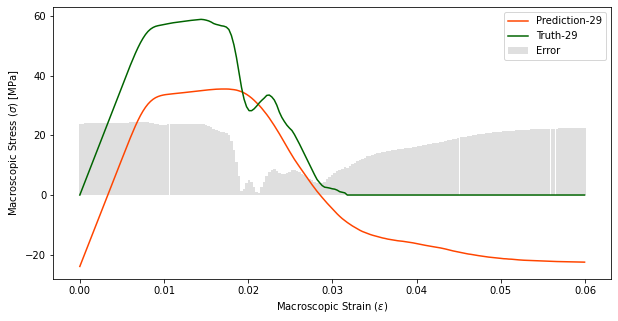

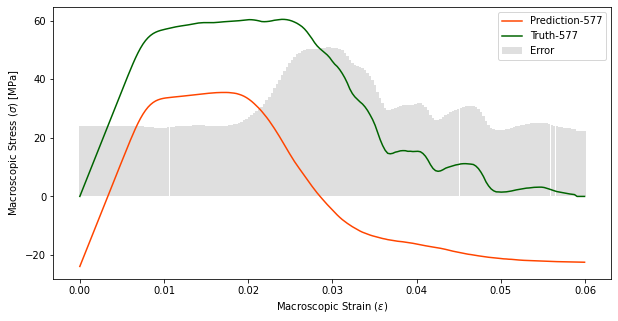

In [32]:
TR1.predict(test_dataloader=None, plot=True)

In [ ]:
for i in range(len(TR1.UT_test_outputs)):
   plot_predictions(DAT.UT_OUT_df, TR1.UT_test_outputs, TR1.UT_truth, indx=i, d_out=False)

## Graph Neural Network (GNN)

In [9]:
DAT_GNN = DATA(
    path=1, 
    path_add="",
    load=True, 
    load_split=False,
    split_frac=0.9,
    save_split=False,
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2,
    d_data="in",
    mechMode="UT",
    nsims=None,
    model="GNN",
    scale=("symm", "inout"),
    reduce_dim=("PCA", "out", 0.95, 10, True)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [10]:
DAT = DAT_GNN
if DAT.UTmechTest:
    print("UT shape:", DAT.UT_train_in.shape, DAT.UT_train_out.shape)
    print("Train -  in (min, max):", DAT.UT_train_in.min(), DAT.UT_train_in.max(), "\n        out (min, max):", DAT.UT_train_out.min(), DAT.UT_train_out.max())
    print("  Val -  in (min, max):", DAT.UT_val_in.min(), DAT.UT_val_in.max(), "\n        out (min, max):", DAT.UT_val_out.min(), DAT.UT_val_out.max())
    print(" Test -  in (min, max):", DAT.UT_test_in.min(), DAT.UT_test_in.max(), "\n        out (min, max):", DAT.UT_test_out.min(), DAT.UT_test_out.max())
    if DAT.FTmechTest: print("\n========================================================\n")
if DAT.FTmechTest:
    print("FT shape:", DAT.FT_train_in.shape, DAT.FT_train_out.shape)
    print("Train -  in (min, max):", DAT.FT_train_in.min(), DAT.FT_train_in.max(), "\n        out (min, max):", DAT.FT_train_out.min(), DAT.FT_train_out.max())
    print("  Val -  in (min, max):", DAT.FT_val_in.min(), DAT.FT_val_in.max(), "\n        out (min, max):", DAT.FT_val_out.min(), DAT.FT_val_out.max())
    print(" Test -  in (min, max):", DAT.FT_test_in.min(), DAT.FT_test_in.max(), "\n        out (min, max):", DAT.FT_test_out.min(), DAT.FT_test_out.max())

UT shape: (5560, 722, 2) (5560, 10)
Train -  in (min, max): -1.0 1.0 
        out (min, max): -1.0 1.0
  Val -  in (min, max): -1.001544246884174 1.0022902592222058 
        out (min, max): -1.134944495587152 1.070364818080257
 Test -  in (min, max): -1.0020848730952945 1.0018308995140748 
        out (min, max): -1.063863964365229 0.9643918524698332


[MODEL scan] strict matches: 0
[MODEL scan] coarse-only matches: 0


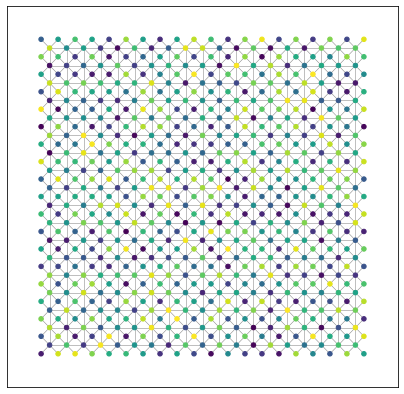

Layer (type:depth-idx)                   Output Shape              Param #
GNN                                      [36, 10]                  --
â”œâ”€GATConv: 1-1                           [25992, 8]                24
â”‚    â””â”€Linear: 2-1                       [25992, 8]                16
â”‚    â””â”€SumAggregation: 2-2               [25992, 2, 4]             --
â”œâ”€LayerNorm: 1-2                         [25992, 8]                16
â”œâ”€ReLU: 1-3                              [25992, 8]                --
â”œâ”€Dropout: 1-4                           [25992, 8]                --
â”œâ”€ModuleList: 1-11                       --                        (recursive)
â”‚    â””â”€gatBlock: 2-3                     [25992, 16]               --
â”‚    â”‚    â””â”€GATConv: 3-1                 [25992, 16]               176
â”‚    â”‚    â””â”€LayerNorm: 3-2               [25992, 16]               32
â”‚    â”‚    â””â”€ReLU: 3-3                    [25992, 16]               --
â”œâ”€Dropout

In [11]:
GNN1 = MODEL(
    typ=DAT.model,
    model=GNN(in_size=DAT.UT_train_in.shape[-1], 
              h_size=[4, 8, 32, 112, 201],
              out_size=DAT.UT_train_out.shape[-1], 
              act="relu",
              block="gat",
              norm="layer",
              dropout=0.2,
              bias=True,
              heads=2,
              pool="add").to(device),
    lossf=nn.MSELoss(reduction="mean"), #CustomQuantileLossMATLAB(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(67, 134), err_type="L2"), #
    # lossf = [CustomQuantileLoss(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(50, 150), err_type="L2"),
    #          CustomPhysicalRegularizationLoss(delta_tolerance=0.0, epsilon_tolerance=1.0, epsilon_decay=2.0, oscillation_power=2.0, reduction="mean"),
    #          CustomStrainEnergyLoss(x_values=None, fracture_indices=None, reduction="mean")],
    opt=("adam", 6.016e-6), #("adam", 1e-4),
    batch=36,
    lr=9e-4,
    data=DAT,
    mechMode=DAT.mechMode,
    scheduler=("min", 0.2427, 100, 1e-4), 
    earlyStop=EarlyStopping(patience=150, min_delta=1e-4, verbose=True),
    w_init="auto",
    device=device,
    optTrial=None,
    scan_matches_on_init=True
)

GNN1.summary()

In [ ]:
GNN1.train(n_epochs=1000, verbose=20, plot=True)

In [ ]:
GNN1.save(path=None, name=None)

In [ ]:
GNN1.predict(test_dataloader=None, plot=True)

In [ ]:
for i in range(len(GNN1.UT_test_outputs)):
    plot_predictions(DAT.UT_OUT_df, GNN1.UT_test_outputs, GNN1.UT_truth, indx=i, d_out=False)

# ETC

In [ ]:
# from resources.calculations import calcUT, calcFT

# class CustomPhysicalRegularizationLoss(nn.Module):
#     """
#     Penalizes high point-to-point oscillations in predicted output curves.
#     - Oscillation penalty starts once |y_j - y_{j-1}| exceeds delta_tolerance.
#     - Penalty weight decays after epsilon_tolerance as epsilon increases.
#     """
#     def __init__(
#         self,
#         delta_power=2.0,
#         epsilon_tolerance=1.0,
#         epsilon_decay=2.0,
#         reduction="mean",
#     ):
#         super().__init__()
#         self.epsilon_tolerance = float(epsilon_tolerance)
#         self.epsilon_decay = float(epsilon_decay)
#         self.oscillation_power = float(delta_power)
#         self.reduction = reduction.lower()

#     def _strain_weights(self, n_diffs, y_pred):
#         # Differences are defined between consecutive points; use mid-point epsilon.
#         eps = torch.linspace(0.0, 1.0, steps=n_diffs + 1, device=y_pred.device, dtype=y_pred.dtype)
#         eps_mid = 0.5 * (eps[1:] + eps[:-1])
#         print(eps_mid)
#         weights = torch.where(
#             eps_mid <= self.epsilon_tolerance,
#             torch.ones_like(eps_mid),
#             torch.exp(-self.epsilon_decay * (eps_mid - self.epsilon_tolerance)),
#         )
#         return weights

#     def forward(self, y_pred, y_true, typ):
#         self.delta_tolerance = (y_true.max() - y_true.min()) / 100

#         diffs = torch.abs(y_pred[:, 1:] - y_pred[:, :-1])
#         excess = torch.relu(diffs - self.delta_tolerance)
#         if self.oscillation_power != 1.0:
#             excess = excess ** self.oscillation_power
#         weights = self._strain_weights(diffs.shape[1], y_pred).unsqueeze(0)
#         print(excess.shape, weights.shape)
#         penalty = excess * weights

#         if self.reduction == "sum":
#             return penalty.sum()
#         if self.reduction == "none":
#             return penalty
#         return penalty.mean()

# test = CustomPhysicalRegularizationLoss(delta_power=2.0, epsilon_tolerance=0.4, epsilon_decay=5.0, reduction="mean")

In [ ]:
# test(torch.Tensor(DAT.UT_test_out), torch.Tensor(DAT.UT_test_out), "UT")

In [ ]:
# class CustomStrainEnergyLoss(nn.Module):
#     """
#     Squared error between integrated predicted and target curves up to fracture index.
#     fracture_indices can be:
#     - None: integrate full curve
#     - 1D tensor/list/ndarray of per-sample indices
#     - callable(batch_size, n_points, device) -> indices
#     """
#     def __init__(self, x_values=None, fracture_indices=None, reduction="mean"):
#         super().__init__()
#         self.fracture_indices = fracture_indices
#         self.reduction = reduction.lower()
#         if x_values is None:
#             self.register_buffer("x_values", torch.tensor([], dtype=torch.float32), persistent=False)
#         else:
#             self.register_buffer("x_values", torch.tensor(x_values, dtype=torch.float32), persistent=False)

#     def _get_fracture_indices(self, batch_size, n_points, device):
#         if self.fracture_indices is None:
#             return torch.full((batch_size,), n_points - 1, dtype=torch.long, device=device)
#         if callable(self.fracture_indices):
#             idx = self.fracture_indices(batch_size=batch_size, n_points=n_points, device=device)
#             return torch.as_tensor(idx, dtype=torch.long, device=device).view(-1)
#         idx = torch.as_tensor(self.fracture_indices, dtype=torch.long, device=device).view(-1)
#         if idx.numel() == 1:
#             idx = idx.repeat(batch_size)
#         if idx.numel() != batch_size:
#             raise ValueError(
#                 f"fracture_indices length ({idx.numel()}) must match batch size ({batch_size}) "
#                 "or be a single scalar."
#             )
#         return idx.clamp(min=0, max=n_points - 1)

#     def _integral_up_to(self, y_row, idx):
#         end = int(idx.item()) + 1
#         if end <= 1:
#             return y_row.new_tensor(0.0)
#         if self.x_values.numel() > 0:
#             if self.x_values.numel() != y_row.numel():
#                 raise ValueError(
#                     f"x_values length ({self.x_values.numel()}) does not match output length ({y_row.numel()})."
#                 )
#             return torch.trapz(y_row[:end], self.x_values[:end].to(y_row.device, y_row.dtype))
#         return torch.trapz(y_row[:end])

#     def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
#         if y_pred.shape != y_true.shape:
#             raise ValueError(f"Shape mismatch: y_pred shape {y_pred.shape} != y_true shape {y_true.shape}")

#         if y_pred.ndim == 1:
#             y_pred = y_pred.unsqueeze(0)
#             y_true = y_true.unsqueeze(0)
#         if y_pred.ndim != 2:
#             raise ValueError(f"Expected 2D tensors [batch, n_points], got ndim={y_pred.ndim}")

#         batch_size, n_points = y_pred.shape
#         fracture_idx = self._get_fracture_indices(batch_size, n_points, y_pred.device)

#         err_sq_terms = []
#         for i in range(batch_size):
#             pred_int = self._integral_up_to(y_pred[i], fracture_idx[i])
#             true_int = self._integral_up_to(y_true[i], fracture_idx[i])
#             err_sq_terms.append((pred_int - true_int) ** 2)
#         err_sq = torch.stack(err_sq_terms)

#         if self.reduction == "sum":
#             return err_sq.sum()
#         if self.reduction == "none":
#             return err_sq
#         return err_sq.mean()

# test1 = CustomStrainEnergyLoss(x_values=None, fracture_indices=None, reduction="mean")

In [ ]:
# test1(torch.Tensor(DAT.FT_test_out), torch.Tensor(DAT.FT_test_out))